# 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Dataset load

In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv('..\\data\\raw\\df_train.csv')

# 3. Descriptive statistics

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,26,62000,RENT,1.0,DEBTCONSOLIDATION,B,10000,11.26,0.16,N,2,0
1,23,39000,MORTGAGE,3.0,EDUCATION,C,5000,12.98,0.13,N,4,0
2,24,35000,RENT,1.0,DEBTCONSOLIDATION,A,12000,6.54,0.34,N,2,1
3,24,86000,RENT,1.0,HOMEIMPROVEMENT,B,12000,10.65,0.14,N,3,0
4,42,38400,RENT,4.0,MEDICAL,B,13000,NaN,0.34,N,11,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22806 entries, 0 to 22805
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  22806 non-null  int64  
 1   person_income               22806 non-null  int64  
 2   person_home_ownership       22806 non-null  str    
 3   person_emp_length           22167 non-null  float64
 4   loan_intent                 22806 non-null  str    
 5   loan_grade                  22806 non-null  str    
 6   loan_amnt                   22806 non-null  int64  
 7   loan_int_rate               20606 non-null  float64
 8   loan_percent_income         22806 non-null  float64
 9   cb_person_default_on_file   22806 non-null  str    
 10  cb_person_cred_hist_length  22806 non-null  int64  
 11  loan_status                 22806 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 2.5 MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,22806.000000,2.280600e+04,22167.000000,22806.000000,20606.000000,22806.000000,22806.000000,22806.000000
mean,27.722880,6.620697e+04,4.796905,9598.740463,11.010418,0.170173,5.797992,0.218144
std,6.336638,6.387456e+04,4.120061,6313.133319,3.228057,0.106759,4.056109,0.412995
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,23.000000,3.852475e+04,2.000000,5000.000000,7.900000,0.090000,3.000000,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000,0.000000
75%,30.000000,7.963500e+04,7.000000,12250.000000,13.470000,0.230000,8.000000,0.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,22.480000,0.830000,30.000000,1.000000


In [7]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 22806
Quantidade de colunas: 12


# 4. Splitting numerical and categorical variables

In [8]:
numerical_cols = df.select_dtypes(include='number')
numerical_cols.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'loan_status'],
      dtype='str')

In [9]:
categorical_cols = df.select_dtypes(include=['object', 'string'])
categorical_cols.columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')

# 5. Univariate analysis

## 5.1. For numerical columns

In [10]:
def calcular_estatisticas_coluna(df, col):
    """Calcula e estrutura todas as métricas estatísticas de uma coluna."""
    stats = {}
    desc = df[col].describe()
    
    # Variabilidade
    stats['mean'] = desc['mean']
    stats['std'] = desc['std']
    stats['cv'] = desc['std'] / desc['mean'] if desc['mean'] != 0 else 0
    stats['range'] = desc['max'] - desc['min']
    
    # Outliers (IQR)
    q25, q75 = desc['25%'], desc['75%']
    stats['iqr'] = q75 - q25
    stats['lim_inf'] = q25 - 1.5 * stats['iqr']
    stats['lim_sup'] = q75 + 1.5 * stats['iqr']
    stats['n_outliers'] = ((df[col] < stats['lim_inf']) | (df[col] > stats['lim_sup'])).sum()
    
    # Forma da Distribuição
    stats['skew'] = df[col].skew()
    stats['kurt'] = df[col].kurtosis()
    
    return stats, desc


def analisar_variaveis_numericas(df, cols_numericas):
    """Executa a análise descritiva completa, gera relatórios organizados e plota gráficos."""
    
    # Dicionário para armazenar os agrupamentos de classificação
    classificacoes = {
        'baixa_var': [], 'moderada_var': [], 'alta_var': [],
        'skew_low': [], 'skew_mod': [], 'skew_high': [],
        'kurt_low': [], 'kurt_mod': [], 'kurt_high': []
    }
    
    for col in cols_numericas:
        # 1. Obter cálculos
        stats, desc = calcular_estatisticas_coluna(df, col)
        
        # 2. Exibir Bloco de Texto Formatado
        print(f"\n" + "="*80)
        print(f"📊 ANÁLISE DA FEATURE: {col.upper()}")
        print("="*80)
        
        print("\n📈 Resumo Estatístico:")
        print(desc.to_string())
        print(f"Amplitude Total (Range): {stats['range']:.2f}")
        
        # Classificação de Variabilidade
        print("\n🔄 Variabilidade (Coeficiente de Variação):")
        if stats['cv'] < 0.3:
            print(f"   • CV = {stats['cv']:.2f} » Baixa variabilidade (Concentrado em torno da média)")
            classificacoes['baixa_var'].append(col)
        elif stats['cv'] >= 0.7:
            print(f"   • CV = {stats['cv']:.2f} » Alta variabilidade (Dados muito dispersos)")
            classificacoes['alta_var'].append(col)
        else:
            print(f"   • CV = {stats['cv']:.2f} » Variabilidade moderada (Pode indicar assimetria/outliers)")
            classificacoes['moderada_var'].append(col)
            
        # Bloco de Outliers
        print("\n🚨 Análise de Outliers (Método IQR):")
        print(f"   • IQR: {stats['iqr']:.2f}  |  Limite Inferior: {stats['lim_inf']:.2f}  |  Limite Superior: {stats['lim_sup']:.2f}")
        print(f"   • Quantidade de Outliers Detectados: {stats['n_outliers']}")
        
        # Classificação de Assimetria (Skewness)
        print("\n📐 Forma da Distribuição (Assimetria & Curtose):")
        abs_skew = abs(stats['skew'])
        if abs_skew < 0.5:
            print(f"   • Assimetria = {stats['skew']:.2f} » Aproximadamente Simétrica")
            classificacoes['skew_low'].append(col)
        elif 0.5 <= abs_skew < 1:
            print(f"   • Assimetria = {stats['skew']:.2f} » Moderadamente Assimétrica")
            classificacoes['skew_mod'].append(col)
        else:
            print(f"   • Assimetria = {stats['skew']:.2f} » Altamente Assimétrica")
            classificacoes['skew_high'].append(col)
            
        # Classificação de Curtose (Kurtosis)
        if stats['kurt'] <= 0:
            print(f"   • Curtose = {stats['kurt']:.2f} » Caudas Leves (Similar à Normal ou Platicúrtica)")
            classificacoes['kurt_low'].append(col)
        elif 0 < stats['kurt'] < 3:
            print(f"   • Curtose = {stats['kurt']:.2f} » Caudas Moderadamente Pesadas")
            classificacoes['kurt_mod'].append(col)
        else:
            print(f"   • Curtose = {stats['kurt']:.2f} » Caudas Muito Pesadas (Presença de valores extremos)")
            classificacoes['kurt_high'].append(col)
            
        # 3. Bloco Visual (Gráficos) com melhorias estéticas
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        
        # Boxplot otimizado
        sns.boxplot(y=df[col].dropna(), ax=ax1, color='#3b82f6', width=0.4)
        ax1.set_title(f"Boxplot de {col}", fontsize=11)
        ax1.set_ylabel("")
        
        # Histograma com curva de densidade sobreposta (KDE)
        sns.histplot(df[col], bins=30, edgecolor='black', color='#2563eb', kde=True, ax=ax2)
        ax2.set_title(f"Histograma de {col}", fontsize=11)
        ax2.set_ylabel("Frequência")
        
        plt.suptitle(f"Distribuição Visual — {col}", fontsize=13, weight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        
    # Retorna o dicionário com os grupos populados para uso posterior
    return classificacoes

In [11]:
calcular_estatisticas_coluna(df, 'loan_amnt')

({'mean': np.float64(9598.740463036043),
  'std': np.float64(6313.133318702072),
  'cv': np.float64(0.657704346003877),
  'range': np.float64(34500.0),
  'iqr': np.float64(7250.0),
  'lim_inf': np.float64(-5875.0),
  'lim_sup': np.float64(23125.0),
  'n_outliers': np.int64(1161),
  'skew': np.float64(1.1949692725492524),
  'kurt': np.float64(1.4656655237713054)},
 count    22806.000000
 mean      9598.740463
 std       6313.133319
 min        500.000000
 25%       5000.000000
 50%       8000.000000
 75%      12250.000000
 max      35000.000000
 Name: loan_amnt, dtype: float64)


📊 ANÁLISE DA FEATURE: PERSON_AGE

📈 Resumo Estatístico:
count    22806.000000
mean        27.722880
std          6.336638
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Amplitude Total (Range): 124.00

🔄 Variabilidade (Coeficiente de Variação):
   • CV = 0.23 » Baixa variabilidade (Concentrado em torno da média)

🚨 Análise de Outliers (Método IQR):
   • IQR: 7.00  |  Limite Inferior: 12.50  |  Limite Superior: 40.50
   • Quantidade de Outliers Detectados: 1020

📐 Forma da Distribuição (Assimetria & Curtose):
   • Assimetria = 2.64 » Altamente Assimétrica
   • Curtose = 20.15 » Caudas Muito Pesadas (Presença de valores extremos)


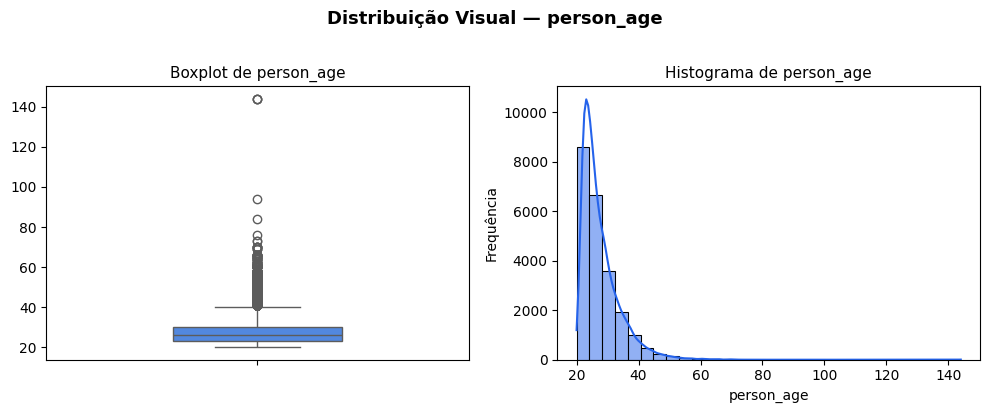


📊 ANÁLISE DA FEATURE: PERSON_INCOME

📈 Resumo Estatístico:
count    2.280600e+04
mean     6.620697e+04
std      6.387456e+04
min      4.000000e+03
25%      3.852475e+04
50%      5.500000e+04
75%      7.963500e+04
max      6.000000e+06
Amplitude Total (Range): 5996000.00

🔄 Variabilidade (Coeficiente de Variação):
   • CV = 0.96 » Alta variabilidade (Dados muito dispersos)

🚨 Análise de Outliers (Método IQR):
   • IQR: 41110.25  |  Limite Inferior: -23140.62  |  Limite Superior: 141300.38
   • Quantidade de Outliers Detectados: 1040

📐 Forma da Distribuição (Assimetria & Curtose):
   • Assimetria = 38.85 » Altamente Assimétrica
   • Curtose = 3317.45 » Caudas Muito Pesadas (Presença de valores extremos)


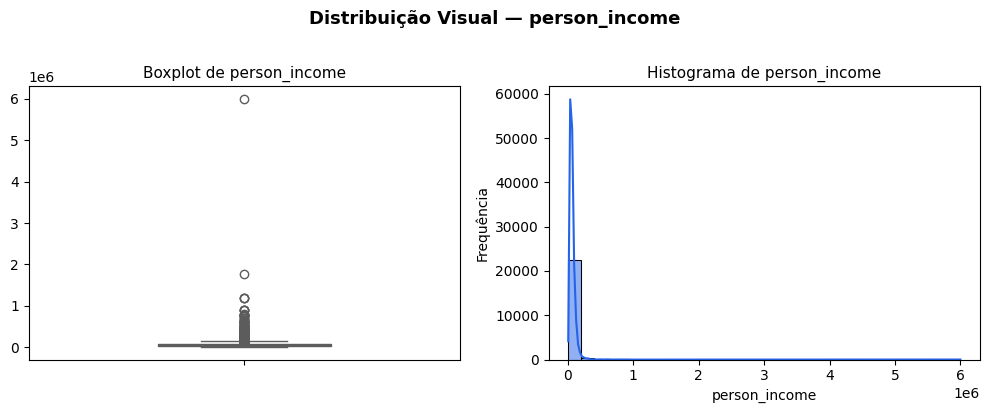


📊 ANÁLISE DA FEATURE: PERSON_EMP_LENGTH

📈 Resumo Estatístico:
count    22167.000000
mean         4.796905
std          4.120061
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Amplitude Total (Range): 123.00

🔄 Variabilidade (Coeficiente de Variação):
   • CV = 0.86 » Alta variabilidade (Dados muito dispersos)

🚨 Análise de Outliers (Método IQR):
   • IQR: 5.00  |  Limite Inferior: -5.50  |  Limite Superior: 14.50
   • Quantidade de Outliers Detectados: 617

📐 Forma da Distribuição (Assimetria & Curtose):
   • Assimetria = 2.24 » Altamente Assimétrica
   • Curtose = 32.53 » Caudas Muito Pesadas (Presença de valores extremos)


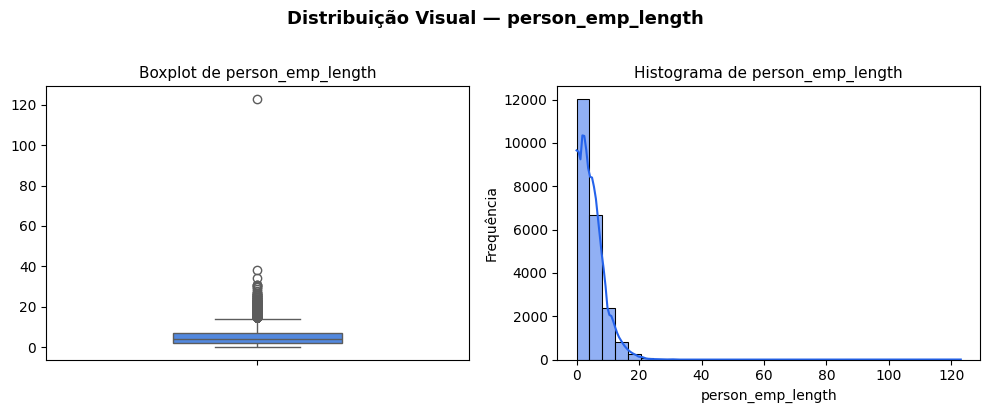


📊 ANÁLISE DA FEATURE: LOAN_AMNT

📈 Resumo Estatístico:
count    22806.000000
mean      9598.740463
std       6313.133319
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12250.000000
max      35000.000000
Amplitude Total (Range): 34500.00

🔄 Variabilidade (Coeficiente de Variação):
   • CV = 0.66 » Variabilidade moderada (Pode indicar assimetria/outliers)

🚨 Análise de Outliers (Método IQR):
   • IQR: 7250.00  |  Limite Inferior: -5875.00  |  Limite Superior: 23125.00
   • Quantidade de Outliers Detectados: 1161

📐 Forma da Distribuição (Assimetria & Curtose):
   • Assimetria = 1.19 » Altamente Assimétrica
   • Curtose = 1.47 » Caudas Moderadamente Pesadas


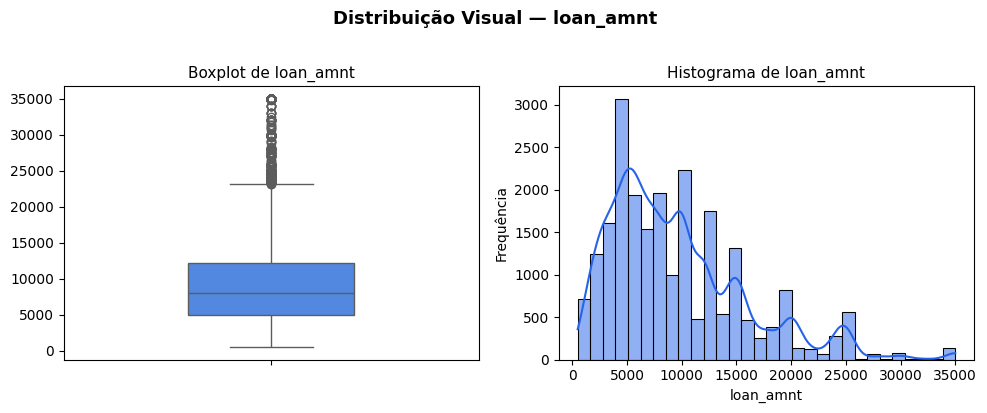


📊 ANÁLISE DA FEATURE: LOAN_INT_RATE

📈 Resumo Estatístico:
count    20606.000000
mean        11.010418
std          3.228057
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         22.480000
Amplitude Total (Range): 17.06

🔄 Variabilidade (Coeficiente de Variação):
   • CV = 0.29 » Baixa variabilidade (Concentrado em torno da média)

🚨 Análise de Outliers (Método IQR):
   • IQR: 5.57  |  Limite Inferior: -0.46  |  Limite Superior: 21.83
   • Quantidade de Outliers Detectados: 3

📐 Forma da Distribuição (Assimetria & Curtose):
   • Assimetria = 0.20 » Aproximadamente Simétrica
   • Curtose = -0.68 » Caudas Leves (Similar à Normal ou Platicúrtica)


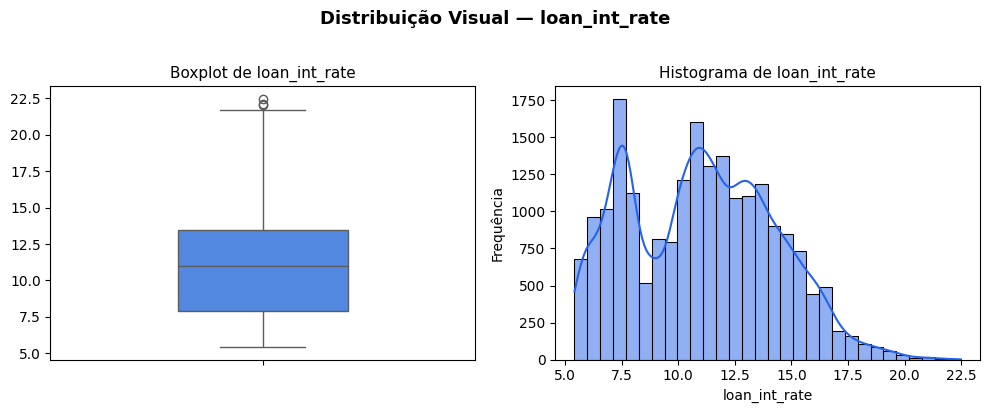


📊 ANÁLISE DA FEATURE: LOAN_PERCENT_INCOME

📈 Resumo Estatístico:
count    22806.000000
mean         0.170173
std          0.106759
min          0.000000
25%          0.090000
50%          0.150000
75%          0.230000
max          0.830000
Amplitude Total (Range): 0.83

🔄 Variabilidade (Coeficiente de Variação):
   • CV = 0.63 » Variabilidade moderada (Pode indicar assimetria/outliers)

🚨 Análise de Outliers (Método IQR):
   • IQR: 0.14  |  Limite Inferior: -0.12  |  Limite Superior: 0.44
   • Quantidade de Outliers Detectados: 461

📐 Forma da Distribuição (Assimetria & Curtose):
   • Assimetria = 1.06 » Altamente Assimétrica
   • Curtose = 1.21 » Caudas Moderadamente Pesadas


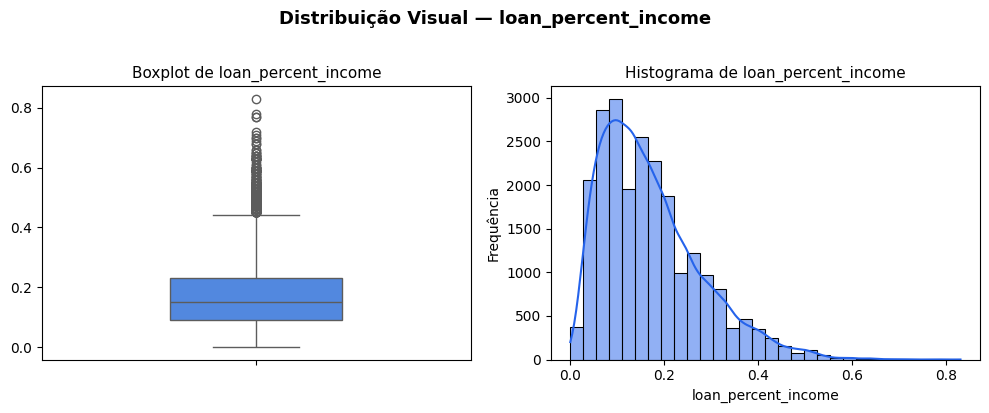


📊 ANÁLISE DA FEATURE: CB_PERSON_CRED_HIST_LENGTH

📈 Resumo Estatístico:
count    22806.000000
mean         5.797992
std          4.056109
min          2.000000
25%          3.000000
50%          4.000000
75%          8.000000
max         30.000000
Amplitude Total (Range): 28.00

🔄 Variabilidade (Coeficiente de Variação):
   • CV = 0.70 » Variabilidade moderada (Pode indicar assimetria/outliers)

🚨 Análise de Outliers (Método IQR):
   • IQR: 5.00  |  Limite Inferior: -4.50  |  Limite Superior: 15.50
   • Quantidade de Outliers Detectados: 800

📐 Forma da Distribuição (Assimetria & Curtose):
   • Assimetria = 1.67 » Altamente Assimétrica
   • Curtose = 3.76 » Caudas Muito Pesadas (Presença de valores extremos)


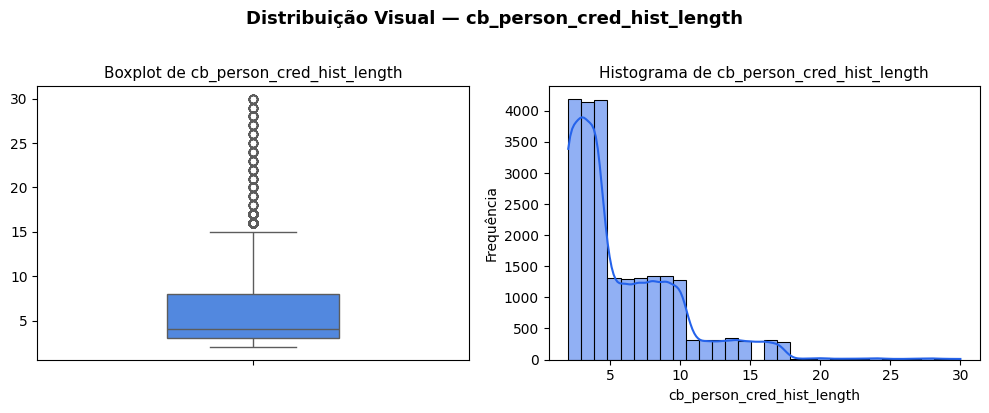

In [12]:
classificacoes = analisar_variaveis_numericas(df, numerical_cols.columns.drop('loan_status').tolist())

In [13]:
# Se precisar acessar qualquer lista depois, elas estão guardadas no dicionário:
print("Variáveis com Alta Variabilidade:", classificacoes['alta_var'])
print("Variáveis Altamente Assimétricas:", classificacoes['skew_high'])

Variáveis com Alta Variabilidade: ['person_income', 'person_emp_length']
Variáveis Altamente Assimétricas: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']


In [14]:
def gerar_tabela_resumo(resultados, numerical_cols):
    """Gera um DataFrame de resumo com as classificações de todas as colunas."""
    resumo_dados = []

    for col in numerical_cols:
        # Identificar Variabilidade
        if col in resultados['baixa_var']: var = "Baixa"
        elif col in resultados['moderada_var']: var = "Moderada"
        elif col in resultados['alta_var']: var = "Alta"
        else: var = "Não classificada"

        # Identificar Assimetria
        if col in resultados['skew_low']: skew = "Baixa (Simétrica)"
        elif col in resultados['skew_mod']: skew = "Moderada"
        elif col in resultados['skew_high']: skew = "Alta (Assimétrica)"
        else: skew = "Não classificada"

        # Identificar Curtose
        if col in resultados['kurt_low']: kurt = "Baixa (Normal)"
        elif col in resultados['kurt_mod']: kurt = "Moderada"
        elif col in resultados['kurt_high']: kurt = "Alta (Caudas Pesadas)"
        else: kurt = "Não classificada"

        resumo_dados.append({
            "Coluna": col,
            "Variabilidade": var,
            "Assimetria": skew,
            "Curtose": kurt
        })

    # Criar o DataFrame final
    df_resumo = pd.DataFrame(resumo_dados)

    return df_resumo

In [15]:
# Gera o relatório consolidado em formato de tabela
df_diagnostico = gerar_tabela_resumo(classificacoes, numerical_cols)
df_diagnostico

,Coluna,Variabilidade,Assimetria,Curtose
0,person_age,Baixa,Alta (Assimétrica),Alta (Caudas Pesadas)
1,person_income,Alta,Alta (Assimétrica),Alta (Caudas Pesadas)
2,person_emp_length,Alta,Alta (Assimétrica),Alta (Caudas Pesadas)
3,loan_amnt,Moderada,Alta (Assimétrica),Moderada
4,loan_int_rate,Baixa,Baixa (Simétrica),Baixa (Normal)
5,loan_percent_income,Moderada,Alta (Assimétrica),Moderada
6,cb_person_cred_hist_length,Moderada,Alta (Assimétrica),Alta (Caudas Pesadas)
7,loan_status,Não classificada,Não classificada,Não classificada


In [16]:
if isinstance(numerical_cols, pd.DataFrame):
    lista_nomes_num = numerical_cols.columns.tolist()
else:
    lista_nomes_num = list(numerical_cols)

# filtra o DataFrame original com a lista de nomes
skewness_series = df[lista_nomes_num].skew()

# Cria o DataFrame de assimetria
skewness_df = pd.DataFrame({
    'Coluna': skewness_series.index,
    'Assimetria': skewness_series.values,
    'Assimetria_Absoluta': skewness_series.abs()
})

# Intervalos estatísticos
bins = [-float('inf'), 0.5, 1.0, float('inf')]
labels = ['Aproximadamente Simétrica', 'Moderadamente Assimétrica', 'Altamente Assimétrica']

# Agrupa e conta
resumo_assimetria = skewness_df.groupby(
    pd.cut(skewness_df['Assimetria_Absoluta'], bins=bins, labels=labels),
    observed=False
).size()

print("Qtd DE VARIÁVEIS POR TIPO DE ASSIMETRIA:\n")
print(resumo_assimetria)

Qtd DE VARIÁVEIS POR TIPO DE ASSIMETRIA:

Assimetria_Absoluta
Aproximadamente Simétrica    1
Moderadamente Assimétrica    0
Altamente Assimétrica        7
dtype: int64


In [17]:
cols_assimetria_alta = skewness_df[skewness_df['Assimetria'] >= 1].sort_values(by='Assimetria', ascending=False)[['Coluna']].values
cols_assimetria_alta

array([['person_income'],
       ['person_age'],
       ['person_emp_length'],
       ['cb_person_cred_hist_length'],
       ['loan_status'],
       ['loan_amnt'],
       ['loan_percent_income']], dtype=object)

### 5.1.1. Insights for numerical features

___

* **Idade do Cliente (`person_age`):**
    * *Comportamento do Gráfico:* O histograma revela uma concentração massiva na base entre 20 e 30 anos (com mediana fixada em 26 anos), indicando um público majoritariamente jovem. Contudo, o boxplot e a linha de densidade (KDE) exibem uma cauda extremamente longa e pesada à direita ($\text{Curtose} = 20.15$), estendendo-se até um valor máximo impossível de **144 anos**.
    * *Insight Técnico:* A distribuição possui forte assimetria positiva induzida por ruídos operacionais de preenchimento de formulário ou falhas de sistema, e não por uma realidade demográfica legítima.
    * *Ação no Pipeline:* Estes valores bizarros precisam ser forçados para `NaN` através de uma regra lógica (`person_age <= 95`) antes da etapa de imputação para evitar distorções nas métricas globais.

* **Renda Anual (`person_income`):**
    * *Comportamento do Gráfico:* Exibe uma assimetria positiva brutal e severa. Enquanto 50% da base (mediana) ganha até R$ 55.000 anuais, a cauda estende-se até um valor máximo de **R$ 6.000.000**, gerando um desvio padrão altíssimo de R$ 63.874.
    * *Insight Técnico:* A renda é o principal vetor de desigualdade no dataset. Modelos estatísticos e algoritmos lineares sofrem forte instabilidade na presença de dispersões e ordens de magnitude tão discrepantes (supersalários).
    * *Ação no Pipeline:* Torna-se obrigatória a aplicação de uma transformação logarítmica (`np.log1p`) nesta variável para estabilizar a variância e aproximar a distribuição de uma curva normal.

* **Tempo de Emprego (`person_emp_length`):**
    * *Comportamento do Gráfico:* O boxplot acusa uma anomalia explícita: um valor máximo registrado de **123 anos de tempo de serviço**. Isolando o ruído, a maioria dos proponentes está no início ou meio da carreira profissional (mediana de 4 anos).
    * *Insight Técnico:* Além do erro grosseiro de preenchimento de dados, há uma quebra de segurança/consistência lógica cruzada: o tempo de emprego não pode ultrapassar a idade do próprio indivíduo.
    * *Ação no Pipeline:* Aplicar a máscara de filtragem `person_emp_length < person_age`, convertendo as inconsistências em `NaN` para posterior tratamento por mediana condicional.

* **Valor do Empréstimo (`loan_amnt`) e Taxa de Juros (`loan_int_rate`):**
    * *Comportamento do Gráfico:* O volume solicitado (`loan_amnt`) possui comportamento multimodal, exibindo picos evidentes em valores redondos (R$ 5.000, R$ 10.000, R$ 15.000), o que reflete o comportamento psicológico humano no ato da solicitação. A taxa de juros (`loan_int_rate`) flutua entre 5,42% e 22,48%, concentrando-se em torno da média de 10,99%.
    * *Insight Técnico:* A taxa de juros é uma das variáveis numéricas mais bem comportadas e livres de ruídos do dataset. Sua distribuição é contínua e reflete as políticas de precificação de risco da instituição.

___


## 5.2. For categorical columns

In [18]:
cols_baixa_variabilidade = []


for col in categorical_cols:
    valores_unicos = df[col].nunique()
    mais_frequente = df[col].mode().iloc[0]
    porcentagem_mais_frequente = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
    porcentagem_menos_frequente = df[col].value_counts(normalize=True, dropna=False).iloc[-1] * 100
    categorias_raras = []
    
    for cat in df[col]:
        try:
            if df[col].value_counts(normalize=True, dropna=False)[cat] < 0.05:
                categorias_raras.append(cat)
        except KeyError:
            pass

    print(f"\n===== {col} =====\n")
    print(f"Contagem de cada categoria:\n{df[col].value_counts(dropna=False)}\n")
    print(f"Categorias raras (menos de 5% dos dados): {set(categorias_raras)}")

    if porcentagem_mais_frequente > 90:
        cols_baixa_variabilidade.append(col)
        print(f"Coluna pode ter baixo poder discriminatório (a categoria -{mais_frequente}- representa {porcentagem_mais_frequente:.2f}% dos dados)")

    if valores_unicos >= 10 and valores_unicos < 30:
        print(f" tem cardinalidade moderada ({valores_unicos} valores únicos)")
    if valores_unicos >= 30 and valores_unicos < 50:
        print(f" tem cardinalidade alta ({valores_unicos} valores únicos)")
    if valores_unicos >= 50:
        print(f"tem cardinalidade muito alta (Não é um bom preditor para modelos lineares)")
    if valores_unicos < 10:
        print(f"tem cardinalidade baixa ({valores_unicos} valores únicos)")


===== person_home_ownership =====

Contagem de cada categoria:
person_home_ownership
RENT        11498
MORTGAGE     9407
OWN          1822
OTHER          79
Name: count, dtype: int64

Categorias raras (menos de 5% dos dados): {'OTHER'}
tem cardinalidade baixa (4 valores únicos)

===== loan_intent =====

Contagem de cada categoria:
loan_intent
EDUCATION            4520
MEDICAL              4237
VENTURE              4007
PERSONAL             3856
DEBTCONSOLIDATION    3668
HOMEIMPROVEMENT      2518
Name: count, dtype: int64

Categorias raras (menos de 5% dos dados): set()
tem cardinalidade baixa (6 valores únicos)

===== loan_grade =====

Contagem de cada categoria:
loan_grade
A    7530
B    7310
C    4575
D    2496
E     676
F     179
G      40
Name: count, dtype: int64

Categorias raras (menos de 5% dos dados): {'E', 'G', 'F'}
tem cardinalidade baixa (7 valores únicos)

===== cb_person_default_on_file =====

Contagem de cada categoria:
cb_person_default_on_file
N    18758
Y     4048
Na

### 5.2.1. Insights for categorical features

* **Status de Habitação (`person_home_ownership`):**
    * *Comportamento do Gráfico:* O gráfico de barras mostra que a esmagadora maioria dos clientes se divide entre quem mora de aluguel (`RENT`) e quem possui financiamento imobiliário ativo (`MORTGAGE`). O volume de clientes com imóvel próprio (`OWN`) ou em outras condições (`OTHER`) é drasticamente menor.
    * *Insight Técnico:* Há um forte desbalanceamento de classes nesta variável. O modelo terá muito mais histórico para aprender sobre proponentes que pagam aluguel ou financiamento do que sobre proprietários diretos.

* **Finalidade do Empréstimo (`loan_intent`):**
    * *Comportamento do Gráfico:* Apresenta uma distribuição volumétrica relativamente bem distribuída entre seis categorias. Os motivos mais frequentes para a solicitação de crédito incluem Educação (`EDUCATION`), Despesas Médicas (`MEDICAL`), Investimentos (*Venture*) e Consolidação de Dívidas (`DEBTCONSOLIDATION`).
    * *Insight Técnico:* Diferente de outras categóricas, esta variável possui boa cardinalidade e equilíbrio entre as classes, o que enriquece a capacidade de segmentação do modelo preditivo sem criar categorias raras/insignificantes.

* **Classe de Risco (`loan_grade`):**
    * *Comportamento do Gráfico:* A distribuição volumétrica segue um formato de pirâmide/decaimento perfeitamente esperado para risco de crédito. As classes `A` e `B` (clientes de melhor score) concentram o maior volume de registros, enquanto as notas mais arriscadas (`E`, `F` e `G`) possuem pouquíssimas observações.
    * *Insight Técnico:* Trata-se de uma variável categórica estritamente ordinal. Embora poucas observações estejam nas faixas de pior risco (`F` e `G`), a presença delas é crítica devido à altíssima densidade de inadimplência histórica concentrada ali.

---

# 6. Bivariate analysis

In [19]:
def gerar_graficos_bivariados(df, target_col='loan_status', cols_para_analisar=None):
    """
    Gera automaticamente gráficos bivariados relacionando as variáveis preditoras
    com a variável alvo (loan_status).
    """
    if cols_para_analisar is None:
        cols_para_analisar = [col for col in df.columns if col != target_col]
        
    paleta = {0: '#1f77b4', 1: '#d62728'} 
    
    for col in cols_para_analisar:
        plt.figure(figsize=(12, 5))
        
    
        if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 2:
            
            # Gráfico 1: Boxplot
            plt.subplot(1, 2, 1)
            sns.boxplot(data=df, x=target_col, y=col, palette=paleta, hue=target_col, legend=False)
            plt.title(f'Boxplot de {col} por {target_col}')
            plt.xlabel('Status do Empréstimo (0 = Pago, 1 = Default)')
            plt.ylabel(col)
            
            # Gráfico 2: KDE plot
            plt.subplot(1, 2, 2)
            sns.kdeplot(data=df, x=col, hue=target_col, palette=paleta, fill=True, common_norm=False, alpha=0.5)
            plt.title(f'Distribuição de Densidade (KDE) de {col}')
            plt.xlabel(col)
            plt.ylabel('Densidade')
            
        # CASO 2: VARIÁVEIS CATEGÓRICAS
        else:
            # Gráfico 1: Countplot
            plt.subplot(1, 2, 1)
            sns.countplot(data=df, x=col, hue=target_col, palette=paleta)
            plt.title(f'Volumetria de {col} por {target_col}')
            plt.xticks(rotation=45, ha='right')
            plt.xlabel(col)
            plt.ylabel('Contagem de Clientes')
            
            # Gráfico 2: Proporção
            plt.subplot(1, 2, 2)
            prop_df = df.groupby(col)[target_col].mean().reset_index()
            prop_df = prop_df.sort_values(by=target_col, ascending=False)
            
            sns.barplot(data=prop_df, x=col, y=target_col, color='#e74c3c')
            plt.axhline(df[target_col].mean(), color='black', linestyle='--', label=f'Taxa Média Base ({df[target_col].mean()*100:.1f}%)')
            plt.title(f'Taxa de Inadimplência por {col}')
            plt.xticks(rotation=45, ha='right')
            plt.xlabel(col)
            plt.ylabel('Proporção de Default')
            plt.legend()

        plt.tight_layout()
        plt.show()

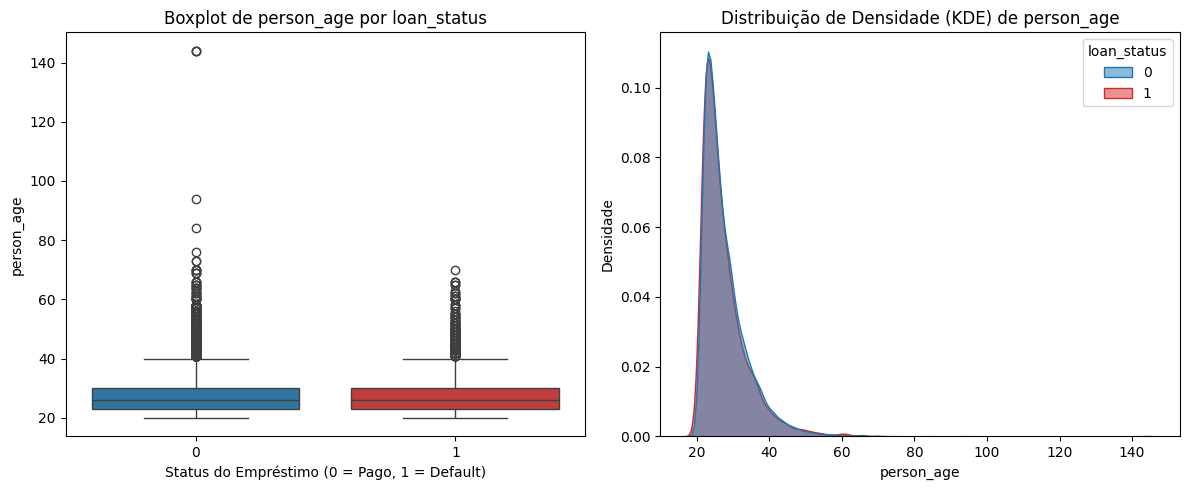

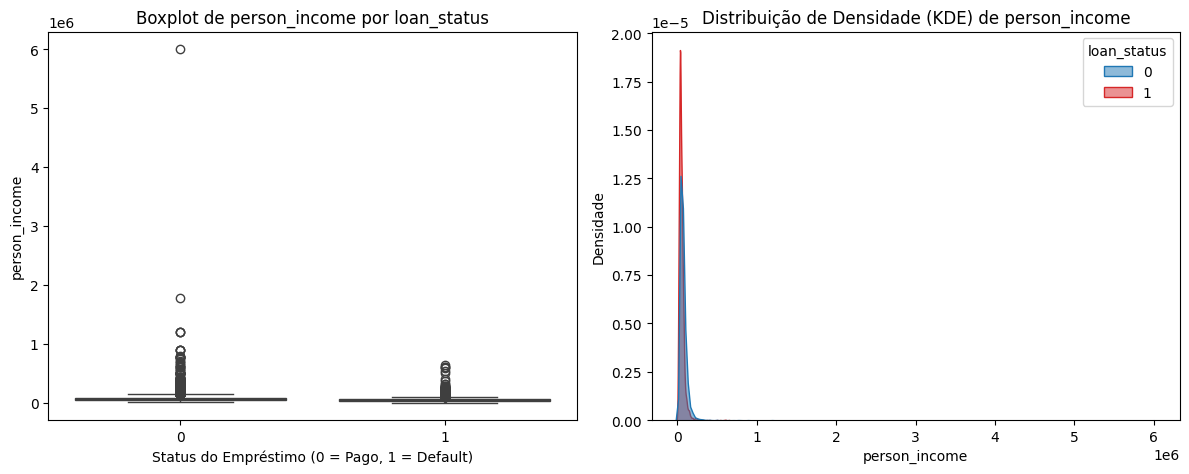

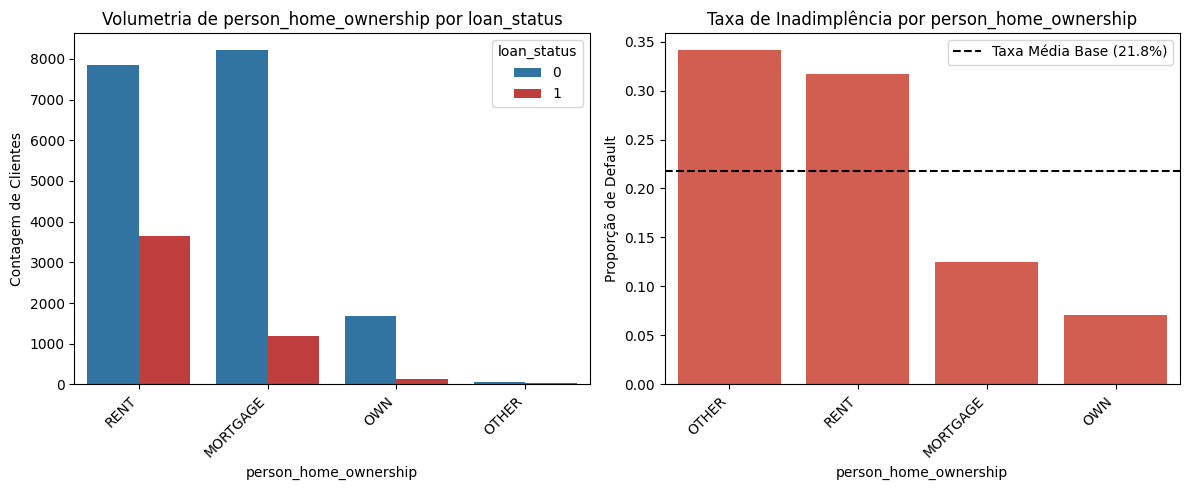

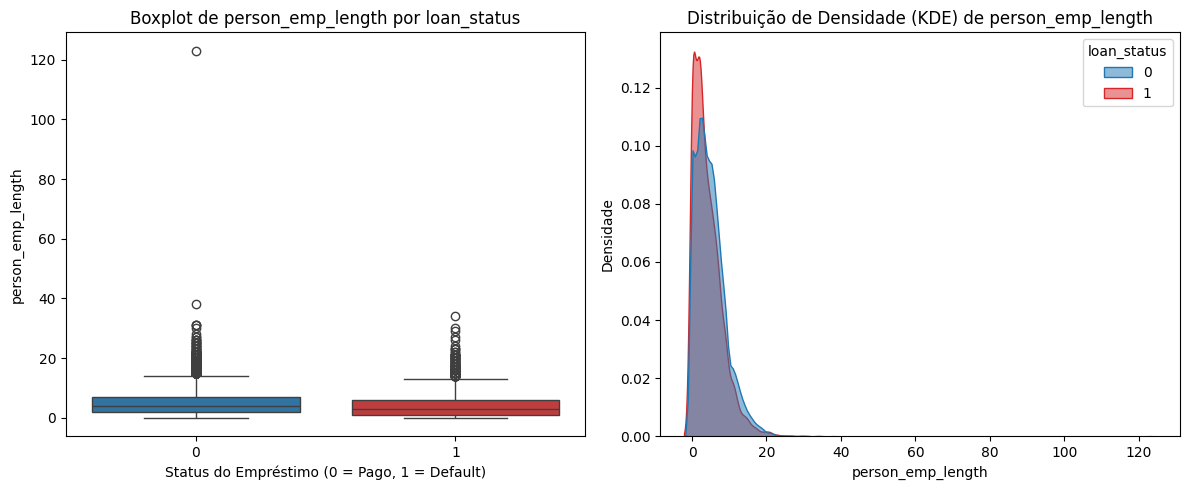

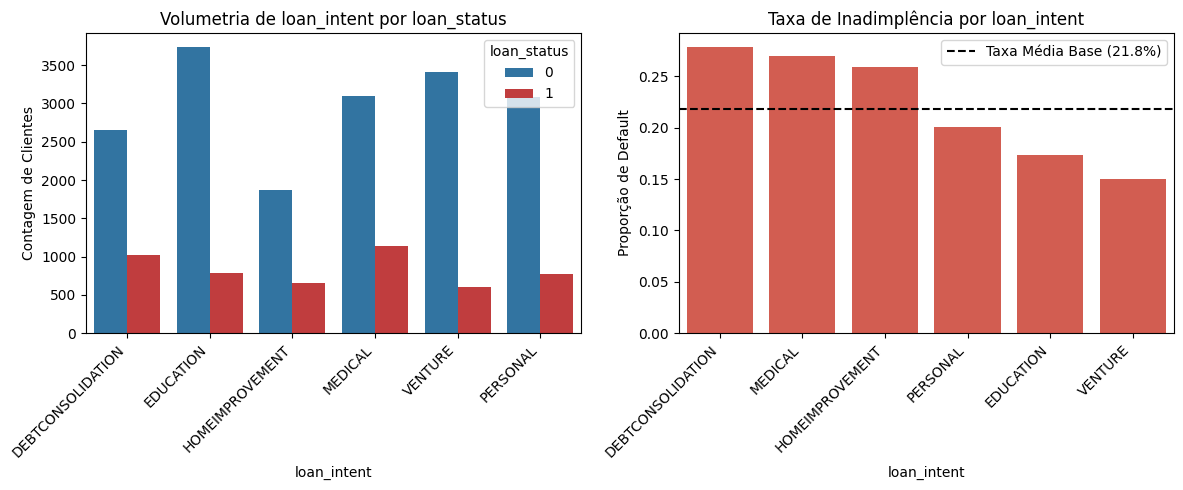

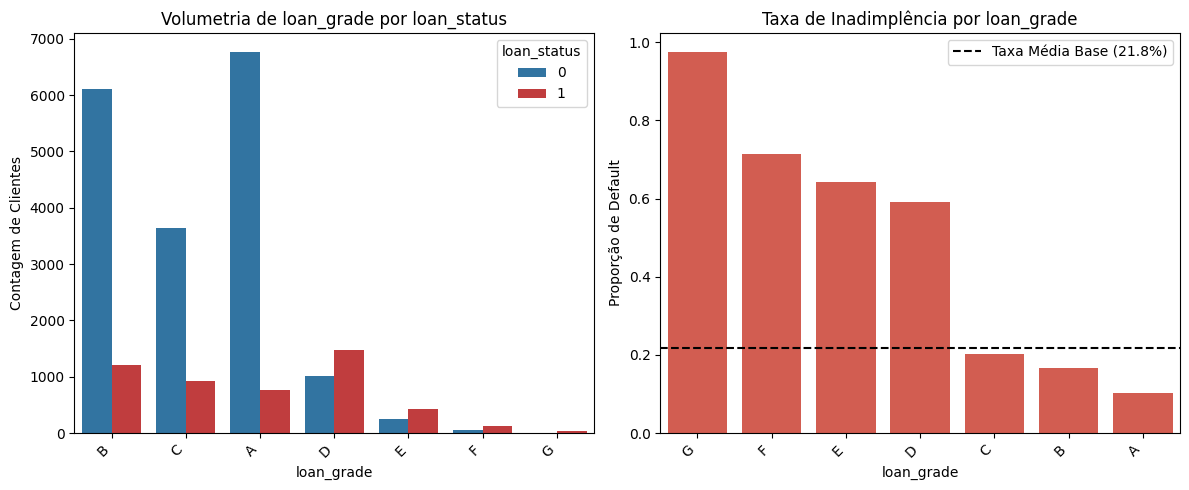

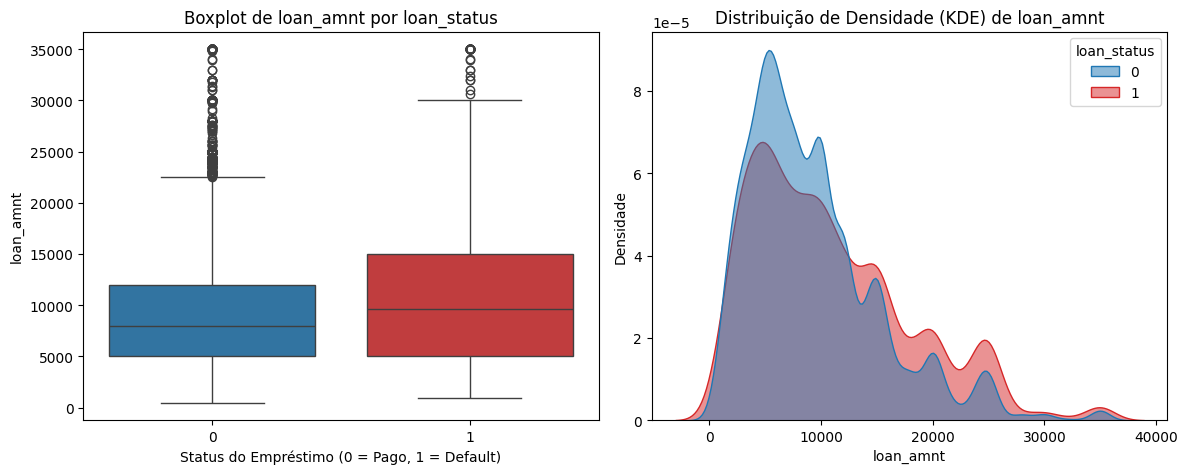

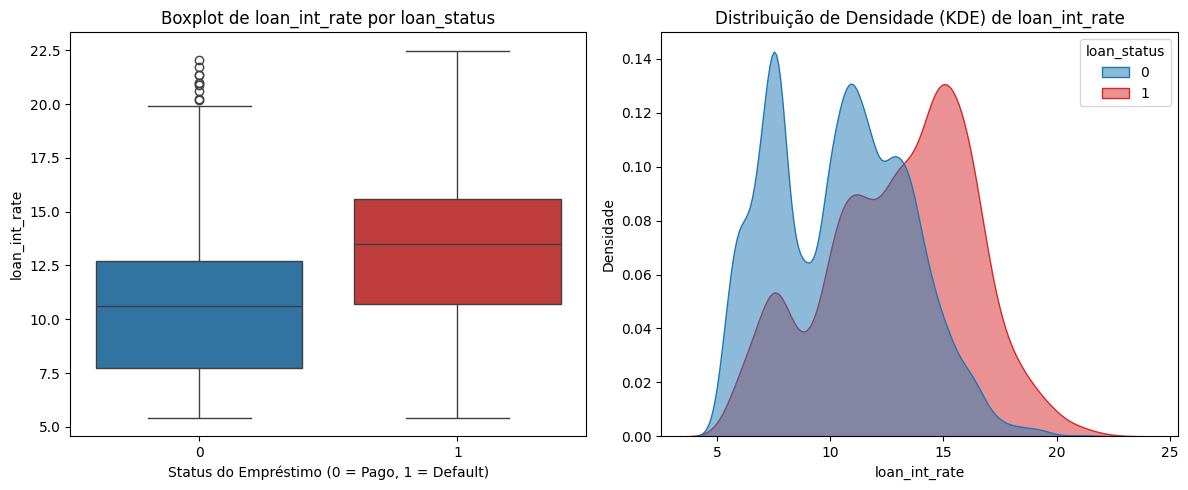

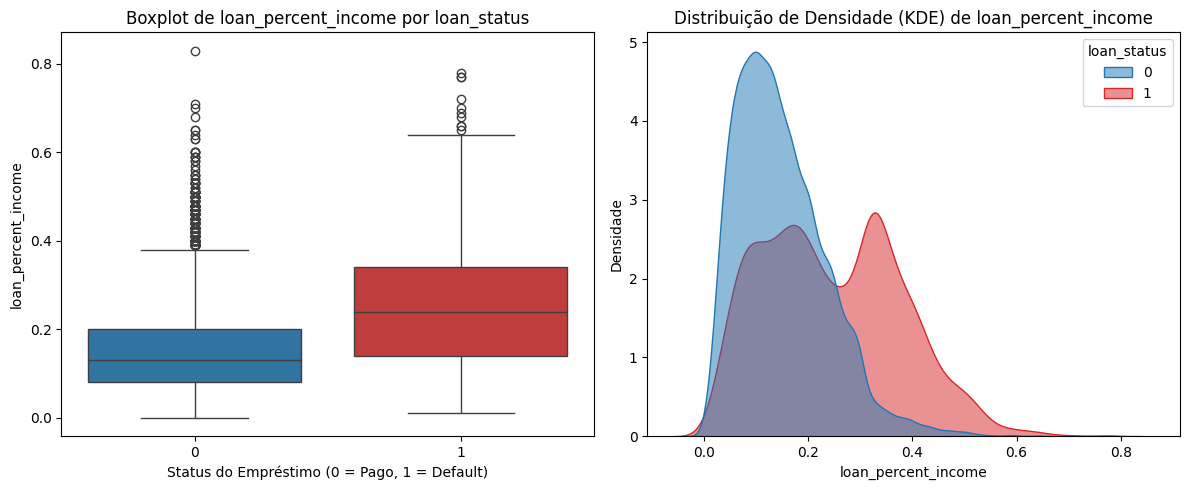

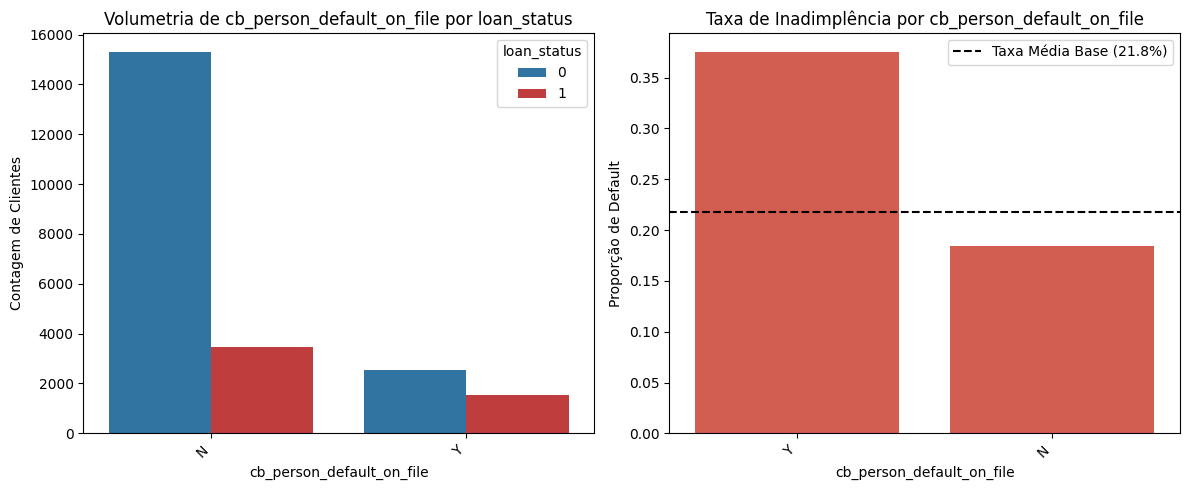

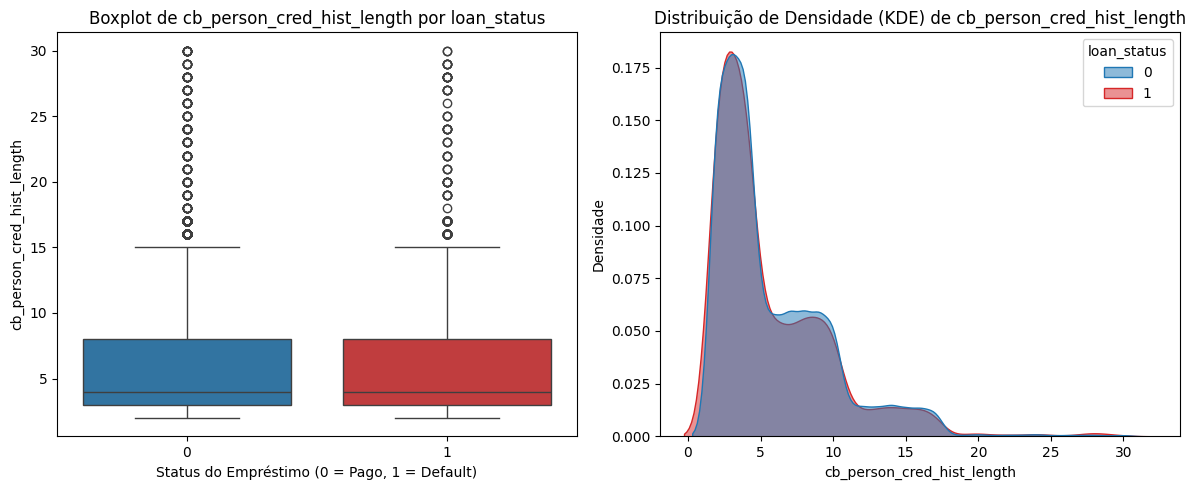

In [20]:
gerar_graficos_bivariados(df, target_col='loan_status')

In [21]:

def plotar_bivariada_sem_outliers(df, colunas_numericas, target='loan_status'):
    """
    Gera automaticamente gráficos bivariados (Boxplot e KDE) para uma lista de 
    colunas numéricas, removendo os outliers de cada uma de forma dinâmica via IQR.
    """
    for col in colunas_numericas:
       
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # Cálculo do IQR
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        limite_superior = q3 + 1.5 * iqr
        
        # Filtra o DataFrame apenas para a coluna correspondente
        df_filtrado = df[df[col] <= limite_superior]
        
        sns.boxplot(
            data=df_filtrado, 
            x=target, 
            y=col, 
            palette='colorblind', 
            hue=target, 
            legend=False,
            ax=axes[0]
        )
        axes[0].set_title(f'Boxplot de {col} por {target}\n(Outliers Removidos via IQR)', fontsize=11, fontweight='bold')
        axes[0].set_xlabel(f'Status do Empréstimo ({target})', fontsize=9)
        axes[0].set_ylabel(col, fontsize=9)
        
        sns.kdeplot(
            data=df_filtrado,
            x=col, 
            hue=target, 
            palette='colorblind', 
            fill=True, 
            common_norm=False, 
            alpha=0.5,
            ax=axes[1]
        )
        axes[1].set_title(f'Distribuição de Densidade (KDE) de {col}\n(Outliers Removidos via IQR)', fontsize=11, fontweight='bold')
        axes[1].set_xlabel(col, fontsize=9)
        axes[1].set_ylabel('Densidade', fontsize=9)
        
        plt.tight_layout()
        plt.show()

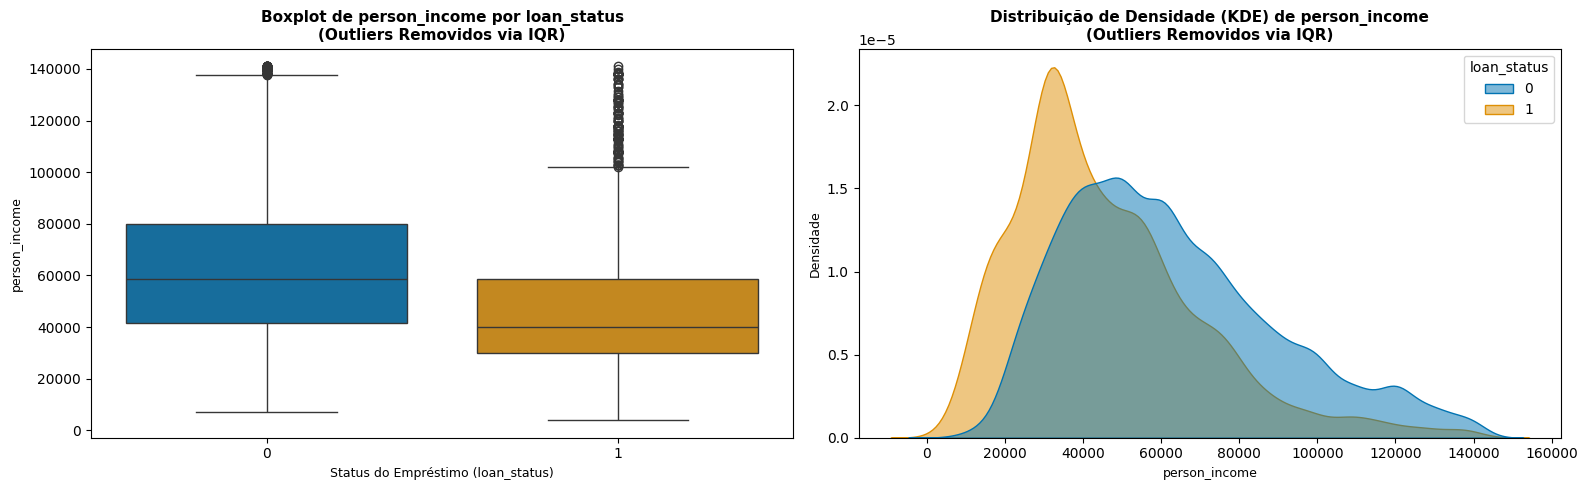

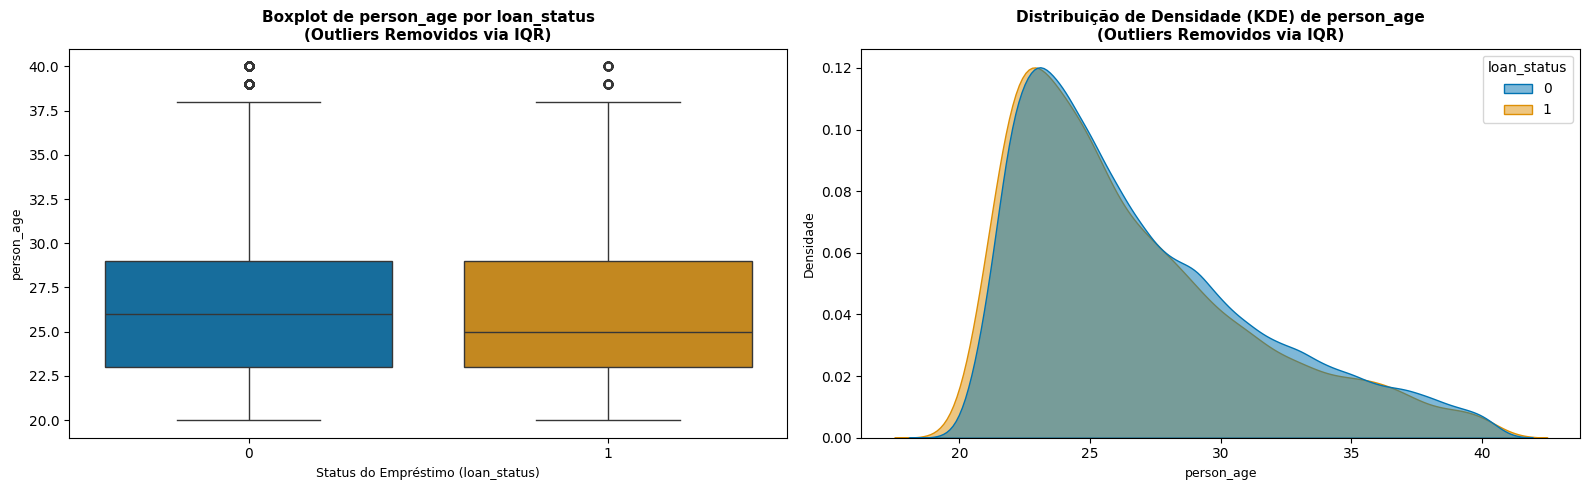

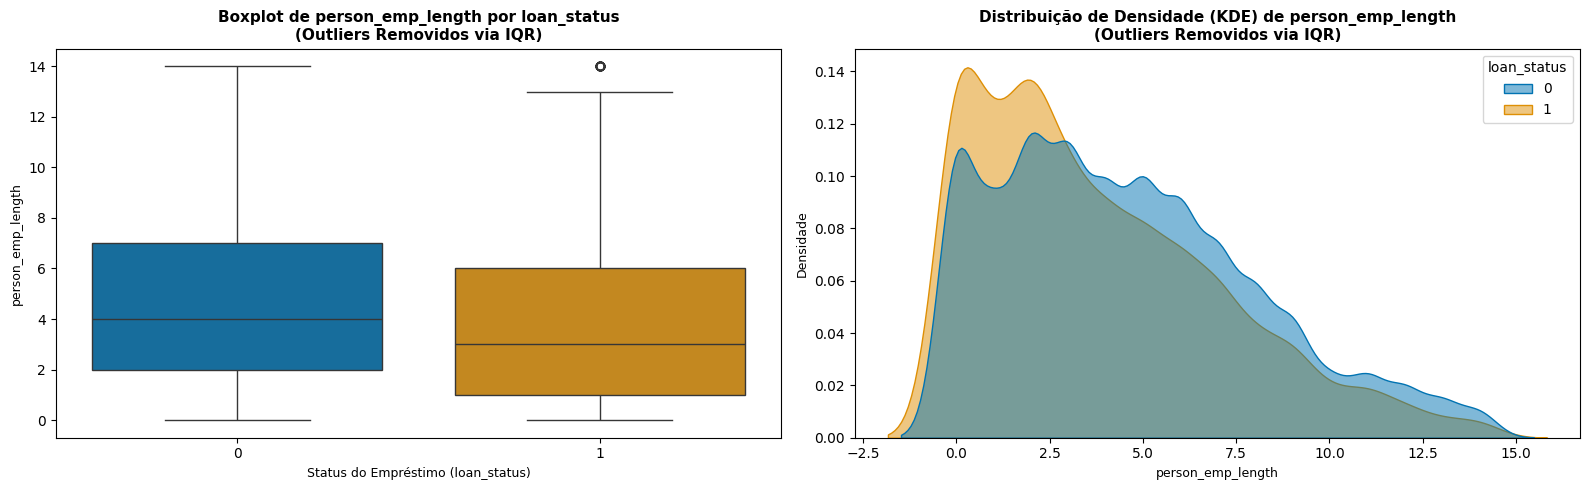

In [22]:
# Lista de colunas onde os boxplots ficaram achatados por causa dos outliers
colunas_para_analisar = ['person_income', 'person_age', 'person_emp_length']

plotar_bivariada_sem_outliers(df, colunas_para_analisar)

## 6.1. Insights for bivariate analysis

___

* **Habitação vs. Inadimplência:** Clientes que residem em imóveis alugados (`RENT`) representam o maior volume absoluto de solicitações e, simultaneamente, exibem a maior taxa proporcional de inadimplência (`loan_status = 1`). Por outro lado, indivíduos com financiamento imobiliário ativo (`MORTGAGE`) demonstram maior estabilidade financeira e menor taxa de default.

* **Finalidade vs. Inadimplência:** O objetivo do crédito é um forte indicador de risco. Empréstimos voltados para **Consolidação de Dívidas (`DEBTCONSOLIDATION`)** e despesas **Médicas (`MEDICAL`)** carregam um risco intrínseco significativamente maior de inadimplência, enquanto finalidades como *Venture* (Empreendedorismo) são estatisticamente mais seguras.

* **Classe de Risco vs. Inadimplência:** A classificação de risco interna opera perfeitamente de forma ordinal e preditiva. À medida que a nota do empréstimo avança de A para G, a taxa de juros aplicada sobe agressivamente e o volume proporcional de inadimplência dispara. As classes D, E, F e G acumulam a maior densidade de maus pagadores do dataset.

---

# 7. Conclusão Geral e Direcionamento de Modelagem

A análise exploratória univariada e bivariada comprova que treinar um modelo preditivo com os dados em seu estado bruto resultaria em um classificador frágil, instável e severamente enviesado devido às assimetrias gritantes e ruídos operacionais.

Para o desenho do pipeline de Machine Learning, estabelecem-se as seguintes diretrizes:

1.  **Limpeza Prévia por Regras de Negócio:** Coagir as idades e tempos de emprego impossíveis para `NaN` para que o imputador trate-os de forma puramente estatística.
2.  **Estabilização da Escala Numérica:** Utilizar o **`RobustScaler`** para as variáveis numéricas. Ao contrário do *StandardScaler*, o *Robust* baseia-se na mediana e nos quartis (IQR), impedindo que os *outliers* legítimos de renda e valor do empréstimo desloquem ou distorçam a escala dos dados.
3.  **Engenharia de Atributos Necessária:** Criar métricas de comprometimento financeiro (ex: razão entre o valor da parcela do empréstimo e a renda anual do cliente) e aplicar `np.log1p` na renda para normalizar sua distribuição.